In [1]:
import pandas as pd

In [2]:
df = pd.read_excel(r'C:\Users\GHSP_EDITOR9\Desktop\MPI\Gender_MPI.xlsx')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246576 entries, 0 to 246575
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Zone                               246576 non-null  object 
 1   State                              246576 non-null  object 
 2   LGA                                246576 non-null  object 
 3   HH No                              246576 non-null  int64  
 4   Household ID                       246576 non-null  int64  
 5   Sex                                246576 non-null  object 
 6   Age in completed years             246576 non-null  int64  
 7   Individual ID                      246576 non-null  object 
 8   Nutrition                          246576 non-null  int64  
 9   Food_Security                      246576 non-null  int64  
 10  Health                             246576 non-null  int64  
 11  School_Attendance                  2465

In [4]:
df[['Nutrition', 'Individual_Weight', 'Population_Weight', 'Household_Weight']].head()

,Nutrition,Individual_Weight,Population_Weight,Household_Weight
0,0,761.459839,3807.299072,676.671265
1,0,761.459839,3807.299072,676.671265
2,0,761.459839,3807.299072,676.671265
3,0,761.459839,3807.299072,676.671265
4,0,761.459839,3807.299072,676.671265


In [13]:
gender_state_agg = df.groupby(['Sex', 'State']).agg({
    'Individual_Weight': 'sum',
    'Population_Weight': 'sum',
    'Household_Weight': 'sum',
    'Nutrition': 'sum',
    'Food_Security': 'sum',
    'Health': 'sum',
    'School_Attendance': 'sum',
    'Years_of_Schooling': 'sum',
    'School_Lag': 'sum',
    'Housing': 'sum',
    'Cooking': 'sum',
    'Asset': 'sum',
    'Unemployment': 'sum',
    'underemployment': 'sum',
    'Security_Shock': 'sum'
})
gender_state_agg.rename(columns={
    'individual_weight': 'weighted_individual_weight',
    'population_weight': 'weighted_population_weight',
    'household_weight': 'weighted_household_weight'
}, inplace=True)

gender_state_agg['weighted_Nutrition'] = df['Nutrition'] * df['Individual_Weight']
gender_state_agg['weighted_Food_Security'] = df['Food_Security'] * df['Individual_Weight'] 
gender_state_agg['weighted_Health'] = df['Health'] * df['Individual_Weight'] 
gender_state_agg['weighted_School_Attendance'] = df['School_Attendance'] * df['Individual_Weight'] 
gender_state_agg['weighted_Years_of_Schooling'] = df['Years_of_Schooling'] * df['Individual_Weight'] 
gender_state_agg['weighted_School_Lag'] = df['School_Lag'] * df['Individual_Weight'] 
gender_state_agg['weighted_Housing'] = df['Housing'] * df['Individual_Weight'] 
gender_state_agg['weighted_Cooking'] = df['Cooking'] * df['Individual_Weight'] 
gender_state_agg['weighted_Asset'] = df['Asset'] * df['Individual_Weight'] 
gender_state_agg['weighted_Unemployment'] = df['Unemployment'] * df['Individual_Weight'] 
gender_state_agg['weighted_underemployment'] = df['underemployment'] * df['Individual_Weight']
gender_state_agg['weighted_Security_Shock'] = df['Security_Shock'] * df['Individual_Weight']



print(gender_state_agg)

                  Individual_Weight  Population_Weight  Household_Weight  \
Sex    State                                                               
Female ABIA            1.921134e+06       8.657591e+06      1.707215e+06   
       ADAMAWA         2.405135e+06       1.811927e+07      2.137323e+06   
       AKWA IBOM       3.568655e+06       2.121066e+07      3.171285e+06   
       ANAMBRA         2.626190e+06       1.230863e+07      2.333764e+06   
       BAUCHI          3.671632e+06       3.024542e+07      3.262796e+06   
...                             ...                ...               ...   
Male   RIVERS          3.444174e+06       1.818040e+07      3.060665e+06   
       SOKOTO          3.308851e+06       2.559752e+07      2.940411e+06   
       TARABA          1.822731e+06       1.417283e+07      1.619770e+06   
       YOBE            1.989369e+06       1.532327e+07      1.767853e+06   
       ZAMFARA         2.751931e+06       2.265820e+07      2.445503e+06   

           

In [16]:
# List of aggregated columns to apply individual weight
aggregated_columns = [
    'Nutrition', 'Food_Security',  # Add other binary columns
]

# Calculate the aggregated individual weight by 'State' and 'Sex'
individual_weight_total = df.groupby(['State', 'Sex'])['Individual_Weight'].sum().reset_index()

# Merge the aggregated individual weight with the original DataFrame
df = pd.merge(df, individual_weight_total, on=['State', 'Sex'], suffixes=('', '_Total'))

# Apply the aggregated individual weight to each aggregated column
for column in aggregated_columns:
    df[f'weighted_{column}'] = df[column] * df['Individual_Weight']

# Aggregate the data by 'State' and 'Sex'
gender_state_agg = df.groupby(['Sex', 'State']).agg({
    f'weighted_{col}': 'sum' for col in aggregated_columns
})

print(gender_state_agg)

                  weighted_Nutrition  weighted_Food_Security
Sex    State                                                
Female ABIA             1.793783e+05            4.802311e+05
       ADAMAWA          7.878535e+05            1.010343e+06
       AKWA IBOM        8.585968e+05            2.159996e+06
       ANAMBRA          2.389355e+05            6.539450e+05
       BAUCHI           7.589230e+05            7.809567e+05
...                              ...                     ...
Male   RIVERS           3.775458e+05            1.732720e+06
       SOKOTO           1.792667e+06            8.468785e+05
       TARABA           6.447106e+05            1.223057e+06
       YOBE             1.121500e+06            9.666792e+05
       ZAMFARA          1.137576e+06            1.098347e+06

[74 rows x 2 columns]


In [23]:
df[['Nutrition', 'Individual_Weight', 'Population_Weight', 'Household_Weight']].head()

,Nutrition,Individual_Weight,Population_Weight,Household_Weight
0,0,761.459839,3807.299072,676.671265
1,0,761.459839,3807.299072,676.671265
2,0,761.459839,3807.299072,676.671265
3,0,761.459839,3807.299072,676.671265
4,0,761.459839,3807.299072,676.671265


In [6]:
print(gender_state_agg.columns)

Index(['weighted_Individual_Weight', 'weighted_Population_Weight',
       'weighted_Household_Weight', 'Nutrition', 'Food_Security', 'Health',
       'School_Attendance', 'Years_of_Schooling', 'School_Lag', 'Housing',
       'Cooking', 'Asset', 'Unemployment', 'underemployment', 'Security_Shock',
       'weighted_Nutrition', 'weighted_Food_Security', 'weighted_Health',
       'weighted_School_Attendance', 'weighted_Years_of_Schooling',
       'weighted_School_Lag', 'weighted_Housing', 'weighted_Cooking',
       'weighted_Asset', 'weighted_Unemployment', 'weighted_underemployment',
       'weighted_Security_Shock'],
      dtype='object')


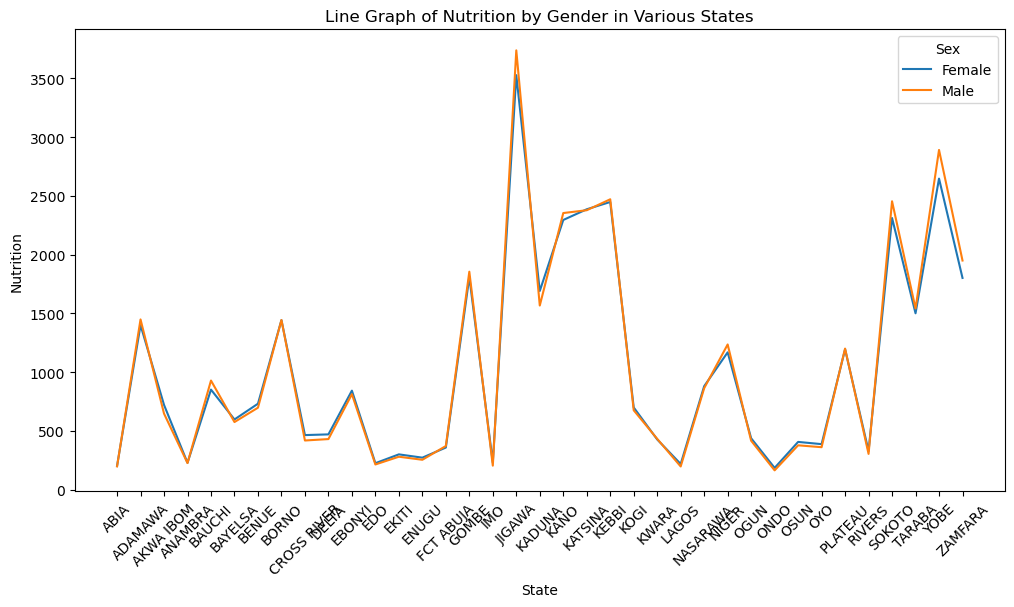

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='State', y='Nutrition', hue='Sex', data=gender_state_agg.reset_index())


plt.xlabel('State')
plt.ylabel('Nutrition')
plt.title('Line Graph of Nutrition by Gender in Various States')


plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.show()

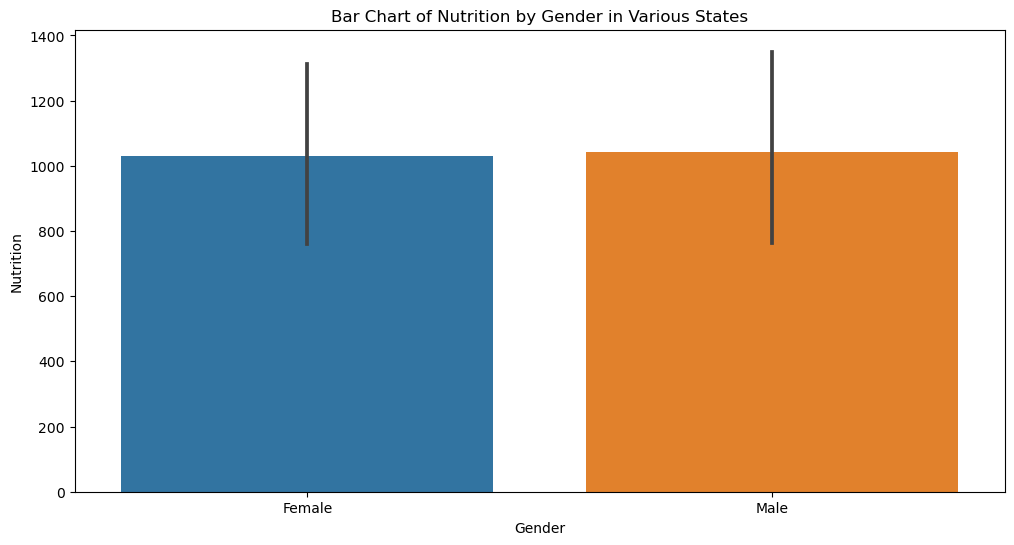

In [20]:
# Create a bar chart for 'Nutrition' by gender
plt.figure(figsize=(12, 6))
sns.barplot(x='Sex', y='Nutrition', data=gender_state_agg)


plt.xlabel('Gender')
plt.ylabel('Nutrition')
plt.title('Bar Chart of Nutrition by Gender in Various States')


plt.show()

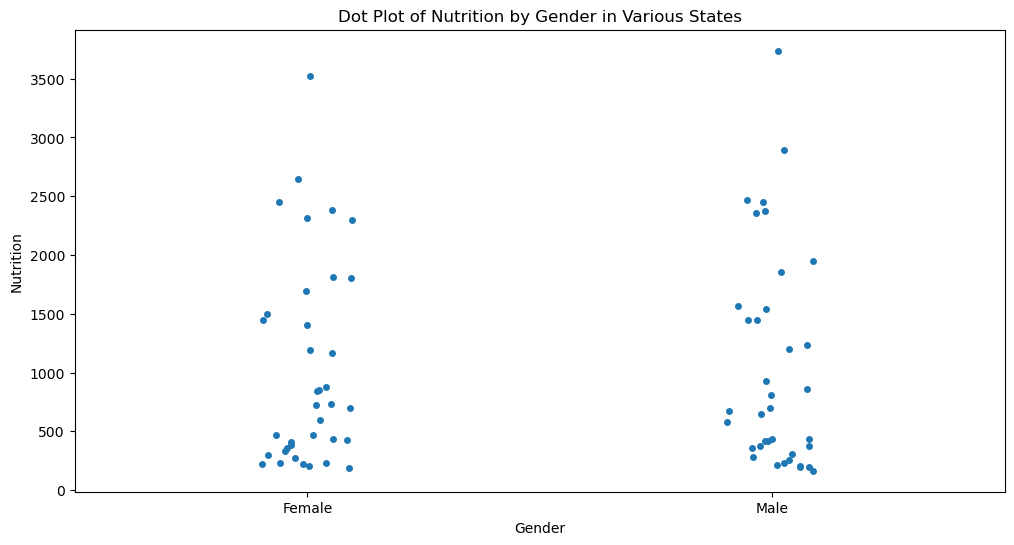

In [21]:
# Create a dot plot for 'Nutrition' by gender
plt.figure(figsize=(12, 6))
sns.stripplot(x='Sex', y='Nutrition', data=gender_state_agg, jitter=True)


plt.xlabel('Gender')
plt.ylabel('Nutrition')
plt.title('Dot Plot of Nutrition by Gender in Various States')


plt.show()